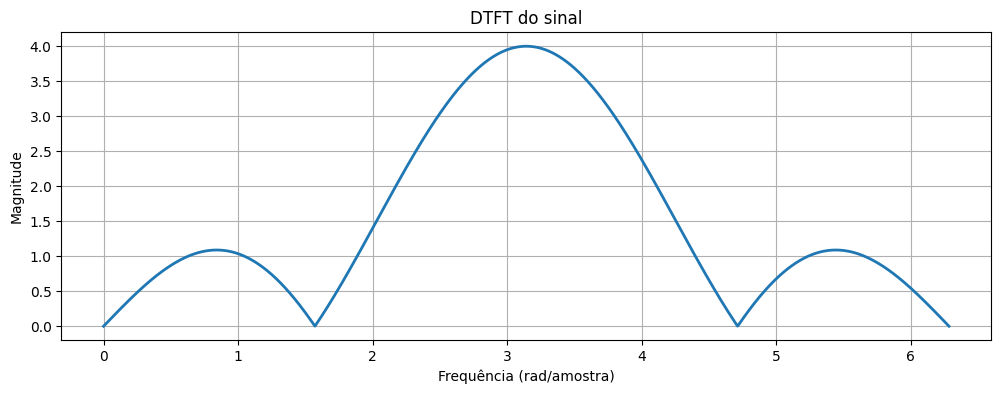

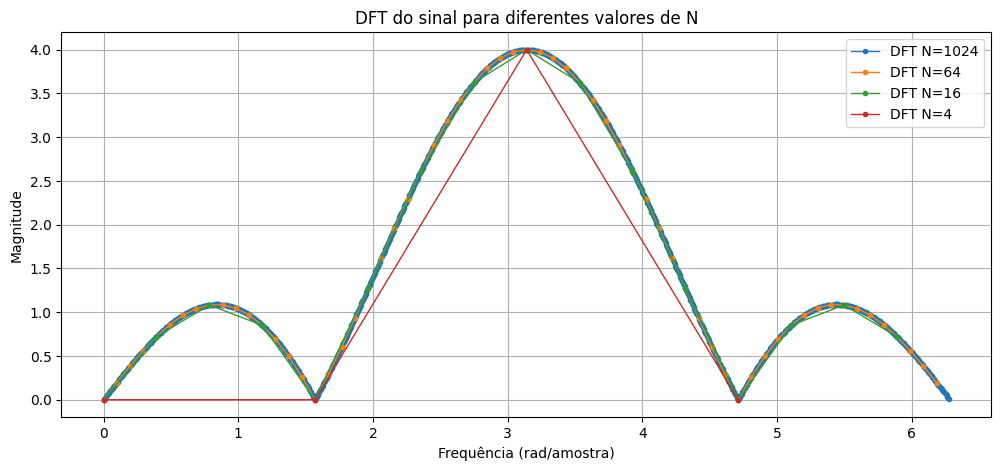

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft

# Valores de N pedidos na questão
valores_N = [4, 16, 64, 1024]

# Definição do sinal x[n]
# x[n] = δ[n] − δ[n−1] + δ[n−2] − δ[n−3]
x = np.array([1, -1, 1, -1])

# Eixo de frequência contínuo para aproximar a DTFT
# Quanto maior a quantidade de pontos, mais suave fica a curva
w = np.linspace(0, 2*np.pi, 4096)

# Cálculo direto da DTFT pela definição
X_dtft = np.zeros(len(w), dtype=complex)
for n in range(len(x)):
    X_dtft += x[n] * np.exp(-1j * w * n)

# Gráfico da DTFT

plt.figure(figsize=(12, 4))
plt.plot(w, np.abs(X_dtft), linewidth=2)
plt.title('DTFT do sinal')
plt.xlabel('Frequência (rad/amostra)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

# Gráfico da DFT com todos os valores de N no mesmo eixo

plt.figure(figsize=(12, 5))

# A ordem de plotagem foi escolhida para que:
# N=1024 fique no fundo e N=4 fique na frente
ordem_plot = [1024, 64, 16, 4]

for N in ordem_plot:
    # Cálculo da DFT com N pontos
    X_dft = fft(x, N)

    # Frequências associadas à DFT
    w_dft = 2 * np.pi * np.arange(N) / N

    # Representação dos pontos da DFT no mesmo gráfico
    plt.plot(
        w_dft,
        np.abs(X_dft),
        marker='o',
        markersize=3,
        linewidth=1,
        label=f'DFT N={N}'
    )

plt.title('DFT do sinal para diferentes valores de N')
plt.xlabel('Frequência (rad/amostra)')
plt.ylabel('Magnitude')
plt.grid()
plt.legend()
plt.show()

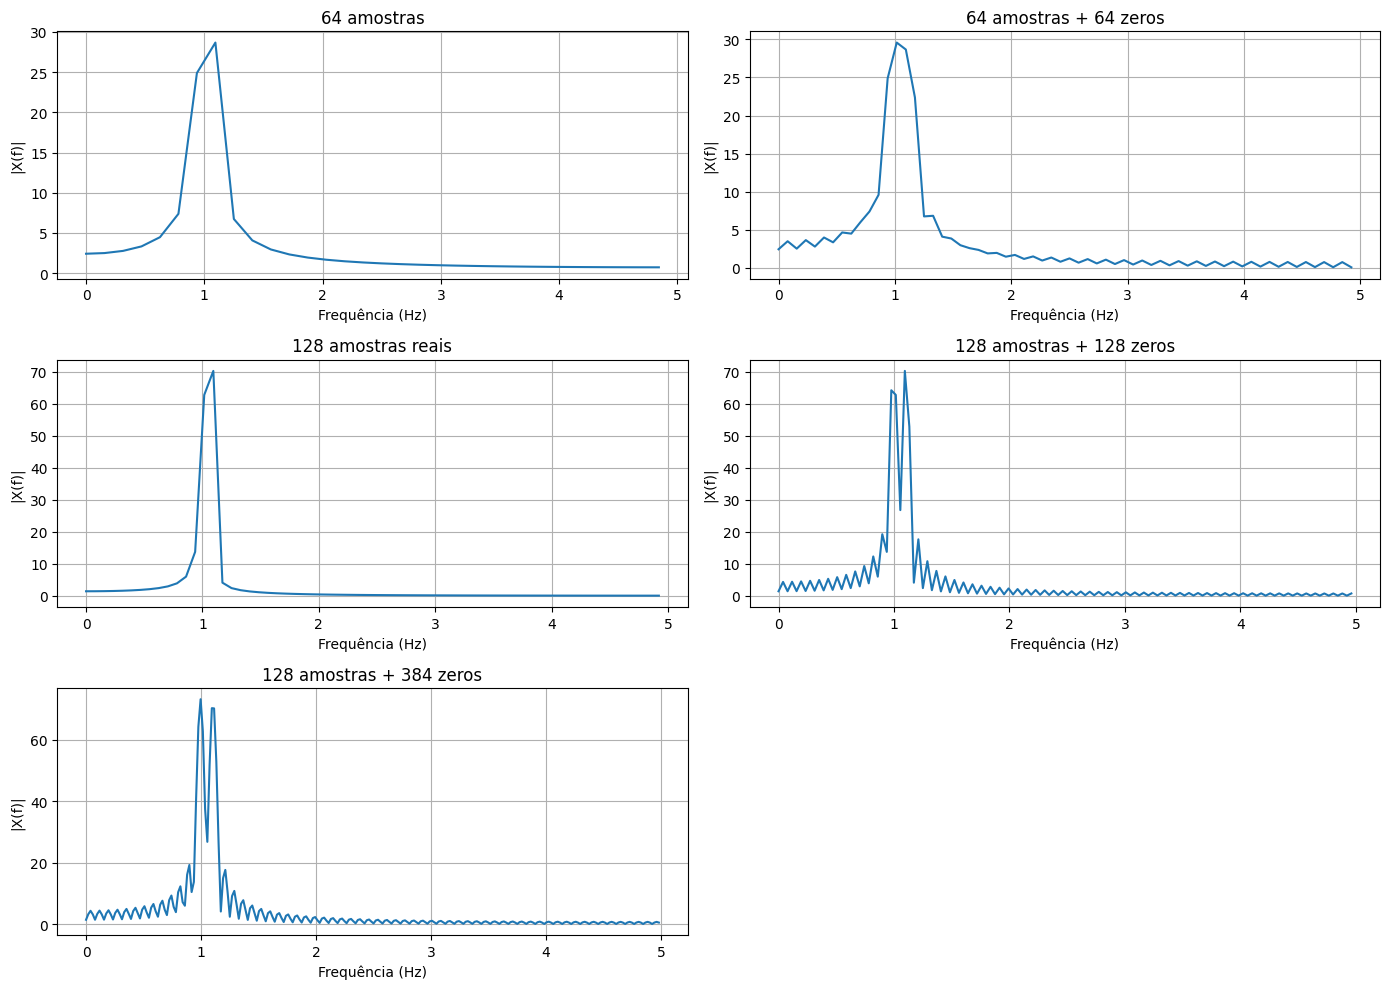

In [46]:
import numpy as np
import matplotlib.pyplot as plt

fs = 10

# 64 amostras

N1 = 64
n1 = np.arange(N1)

x1 = np.sin(2*np.pi*1*n1/fs) + np.sin(2*np.pi*1.1*n1/fs)

X1 = np.fft.fft(x1)
f1 = np.fft.fftfreq(N1, d=1/fs)

# 64 amostras + 64 zeros

x2 = np.pad(x1, (0, 64))

N2 = len(x2)

X2 = np.fft.fft(x2)
f2 = np.fft.fftfreq(N2, d=1/fs)

# 128 amostras reais

N3 = 128
n3 = np.arange(N3)

x3 = np.sin(2*np.pi*1*n3/fs) + np.sin(2*np.pi*1.1*n3/fs)

X3 = np.fft.fft(x3)
f3 = np.fft.fftfreq(N3, d=1/fs)

# 128 amostras + 128 zeros

x4 = np.pad(x3, (0, 128))

N4 = len(x4)

X4 = np.fft.fft(x4)
f4 = np.fft.fftfreq(N4, d=1/fs)

# 128 amostras + 384 zeros

x5 = np.pad(x3, (0, 384))

N5 = len(x5)

X5 = np.fft.fft(x5)
f5 = np.fft.fftfreq(N5, d=1/fs)

# ============================================================
# Gráficos
# ============================================================

plt.figure(figsize=(14,10))

plt.subplot(3,2,1)
plt.plot(f1[:N1//2], np.abs(X1[:N1//2]))
plt.title('64 amostras')
plt.xlabel('Frequência (Hz)')
plt.ylabel('|X(f)|')
plt.grid()

plt.subplot(3,2,2)
plt.plot(f2[:N2//2], np.abs(X2[:N2//2]))
plt.title('64 amostras + 64 zeros')
plt.xlabel('Frequência (Hz)')
plt.ylabel('|X(f)|')
plt.grid()

plt.subplot(3,2,3)
plt.plot(f3[:N3//2], np.abs(X3[:N3//2]))
plt.title('128 amostras reais')
plt.xlabel('Frequência (Hz)')
plt.ylabel('|X(f)|')
plt.grid()

plt.subplot(3,2,4)
plt.plot(f4[:N4//2], np.abs(X4[:N4//2]))
plt.title('128 amostras + 128 zeros')
plt.xlabel('Frequência (Hz)')
plt.ylabel('|X(f)|')
plt.grid()

plt.subplot(3,2,5)
plt.plot(f5[:N5//2], np.abs(X5[:N5//2]))
plt.title('128 amostras + 384 zeros')
plt.xlabel('Frequência (Hz)')
plt.ylabel('|X(f)|')
plt.grid()

plt.tight_layout()
plt.show()

In [28]:
from google.colab import files
import scipy.io.wavfile as wav
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.fftpack import dct, idct
from IPython.display import Audio

# Upload do áudio
uploaded = files.upload()

# Nome do arquivo enviado
nome = list(uploaded.keys())[0]

# Leitura do áudio
fs, audio = wav.read(nome)

# Conversão para float
audio = audio.astype(float)

# Normalização
audio = audio / np.max(np.abs(audio))

# Taxas de compressão pedidas
valores_r = [99.5, 99.0, 90.0, 75.0, 50.0]

# Função que preserva coeficientes até atingir a energia desejada

def manter_energia(coeficientes, percentual_energia):

    # Energia total do conjunto de coeficientes
    energia_total = np.sum(np.abs(coeficientes) ** 2)

    # Índices ordenados pela contribuição energética de cada coeficiente
    indices = np.argsort(np.abs(coeficientes) ** 2)[::-1]

    # Vetor inicialmente zerado
    coeficientes_filtrados = np.zeros_like(coeficientes)

    # Energia acumulada ao longo da seleção
    energia_acumulada = 0.0

    # Número de coeficientes preservados
    quantidade = 0

    for indice in indices:
        coeficientes_filtrados[indice] = coeficientes[indice]
        energia_acumulada += np.abs(coeficientes[indice]) ** 2
        quantidade += 1

        # Para quando a energia acumulada atingir o percentual desejado
        if energia_acumulada >= energia_total * (percentual_energia / 100.0):
            break

    return coeficientes_filtrados, quantidade

# Transformada discreta de Fourier

X_fft = fft(audio)

# Transformada discreta do cosseno

X_dct = dct(audio, norm='ortho')

for r in valores_r:

    # Compressão pela FFT mantendo energia
    fft_comp, n_fft = manter_energia(X_fft, r)

    # Reconstrução pela IFFT
    audio_fft = np.real(ifft(fft_comp))

    # Compressão pela DCT mantendo energia
    dct_comp, n_dct = manter_energia(X_dct, r)

    # Reconstrução pela IDCT
    audio_dct = idct(dct_comp, norm='ortho')

    # Erro quadrático médio
    mse_fft = np.mean((audio - audio_fft) ** 2)
    mse_dct = np.mean((audio - audio_dct) ** 2)

    print(f'Compressão {r}%')
    print(f'FFT -> coeficientes preservados: {n_fft} | EQM: {mse_fft}')
    print(f'DCT -> coeficientes preservados: {n_dct} | EQM: {mse_dct}')

    # Reprodução dos áudios reconstruídos
    display(Audio(audio_fft, rate=fs))
    display(Audio(audio_dct, rate=fs))

Saving handel.wav to handel (2).wav
Compressão 99.5%
FFT -> coeficientes preservados: 48670 | EQM: 0.00030078859451883067
DCT -> coeficientes preservados: 40702 | EQM: 0.0003008024624644778


Compressão 99.0%
FFT -> coeficientes preservados: 40986 | EQM: 0.0006015494316440646
DCT -> coeficientes preservados: 33683 | EQM: 0.0006016167315710154


Compressão 90.0%
FFT -> coeficientes preservados: 11661 | EQM: 0.0060161483061644885
DCT -> coeficientes preservados: 9038 | EQM: 0.006016019484789987


Compressão 75.0%
FFT -> coeficientes preservados: 4325 | EQM: 0.015039429229856155
DCT -> coeficientes preservados: 3200 | EQM: 0.015038450136453845


Compressão 50.0%
FFT -> coeficientes preservados: 1170 | EQM: 0.0300746149912263
DCT -> coeficientes preservados: 835 | EQM: 0.030073965375828914


Saving sosias.jpg to sosias.jpg


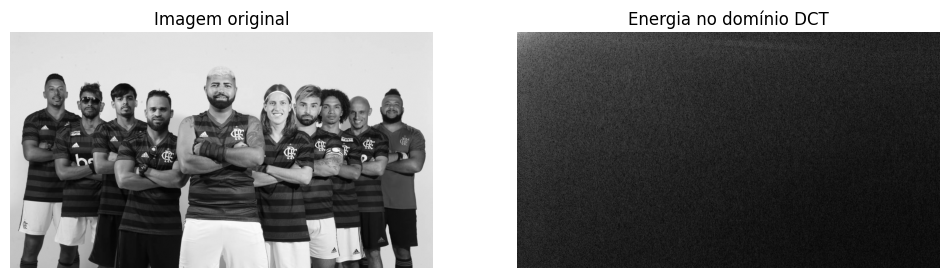

In [22]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct

# Upload da imagem
uploaded = files.upload()

# Nome do arquivo
nome_imagem = list(uploaded.keys())[0]

# Leitura em escala de cinza
imagem = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)

# Conversão para float
imagem = imagem.astype(float)

# DCT 2D

# DCT nas linhas
dct_linhas = dct(imagem, axis=0, norm='ortho')

# DCT nas colunas
dct_2d = dct(dct_linhas, axis=1, norm='ortho')

# Magnitude logarítmica
espectro = np.log(np.abs(dct_2d) + 1)

# Plot

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(imagem, cmap='gray')
plt.title('Imagem original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(espectro, cmap='gray')
plt.title('Energia no domínio DCT')
plt.axis('off')

plt.show()

Saving sosias.jpg to sosias (9).jpg
L =  8 | r = 95% | coeficientes mantidos = 95569/2419200 (3.95%) | MSE = 0.00202236
L =  8 | r = 50% | coeficientes mantidos = 38394/2419200 (1.59%) | MSE = 0.00684405
L = 64 | r = 95% | coeficientes mantidos = 25974/2568192 (1.01%) | MSE = 0.00913550
L = 64 | r = 50% | coeficientes mantidos = 739/2568192 (0.03%) | MSE = 0.03913615


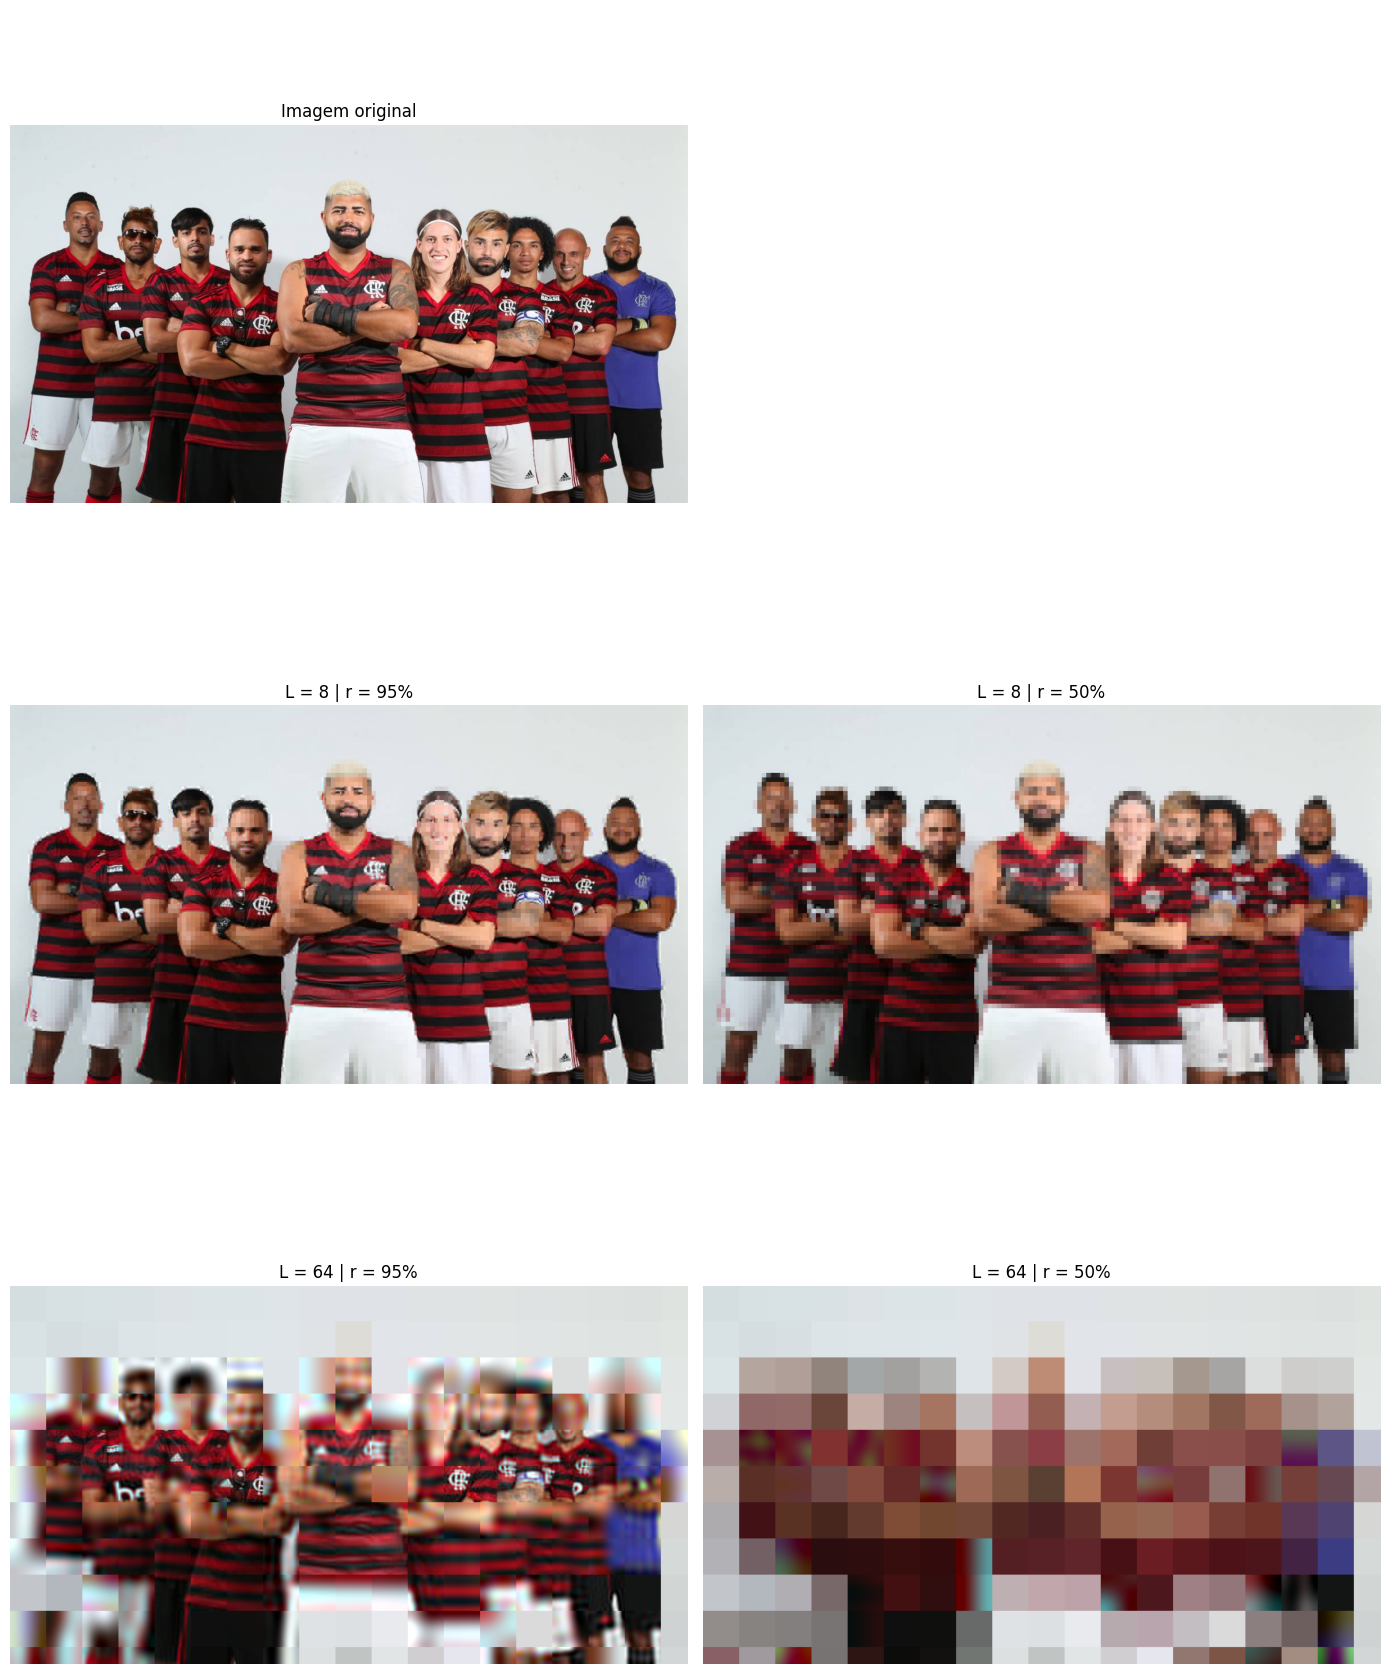


Resumo:
L= 8 | r=95% | mantidos=95569/2419200 | EQM=0.00202236
L= 8 | r=50% | mantidos=38394/2419200 | EQM=0.00684405
L=64 | r=95% | mantidos=25974/2568192 | EQM=0.00913550
L=64 | r=50% | mantidos=739/2568192 | EQM=0.03913615


In [37]:
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

# Upload da imagem

uploaded = files.upload()
img_name = next(iter(uploaded))


# Leitura da imagem

img_pil = Image.open(BytesIO(uploaded[img_name]))

# Mantém RGB se a imagem for colorida; caso contrário, usa escala de cinza
if img_pil.mode in ("RGB", "RGBA"):
    img = np.array(img_pil.convert("RGB"), dtype=np.float32) / 255.0
    color = True
else:
    img = np.array(img_pil.convert("L"), dtype=np.float32) / 255.0
    color = False

# Função para gerar ordem zigzag

def zigzag_order(L):
    order = []
    for s in range(2 * L - 1):
        if s % 2 == 0:
            i = min(s, L - 1)
            j = s - i
            while i >= 0 and j < L:
                order.append((i, j))
                i -= 1
                j += 1
        else:
            j = min(s, L - 1)
            i = s - j
            while j >= 0 and i < L:
                order.append((i, j))
                i += 1
                j -= 1
    return np.array(order, dtype=np.int32)

# Compressão por blocos via DCT
# Mantém coeficientes em ordem zigzag (frequência), usando limiar de energia r

def compress_channel(channel, L, r):
    h, w = channel.shape
    pad_h = (L - (h % L)) % L
    pad_w = (L - (w % L)) % L

    padded = np.pad(channel, ((0, pad_h), (0, pad_w)), mode="edge")
    ph, pw = padded.shape

    zz = zigzag_order(L)
    zz_r = zz[:, 0]
    zz_c = zz[:, 1]

    recon = np.zeros_like(padded, dtype=np.float32)
    total_coeffs = 0
    kept_coeffs = 0

    for y in range(0, ph, L):
        for x in range(0, pw, L):
            block = padded[y:y+L, x:x+L].astype(np.float32)

            # DCT 2-D
            dct_block = cv2.dct(block)

            # Varre em zigzag (baixas frequências primeiro)
            vec = dct_block[zz_r, zz_c]
            energy = vec ** 2
            total_energy = float(np.sum(energy))

            total_coeffs += L * L

            if total_energy == 0.0:
                kept = np.zeros_like(vec)
                k = 0
            else:
                cum_energy = np.cumsum(energy)
                target = r * total_energy
                k = int(np.searchsorted(cum_energy, target, side="left")) + 1
                k = max(1, min(k, L * L))
                kept = np.zeros_like(vec)
                kept[:k] = vec[:k]

            kept_coeffs += k

            # Reconstrói o bloco pela IDCT
            kept_block = np.zeros((L, L), dtype=np.float32)
            kept_block[zz_r, zz_c] = kept
            rec_block = cv2.idct(kept_block)

            recon[y:y+L, x:x+L] = rec_block

    # Recorta para o tamanho original
    recon = recon[:h, :w]
    recon = np.clip(recon, 0.0, 1.0)

    mse = np.mean((channel - recon) ** 2)
    return recon, mse, kept_coeffs, total_coeffs

# Processa a imagem inteira

def compress_image(img, L, r):
    if img.ndim == 2:
        recon, mse, kept, total = compress_channel(img, L, r)
        return recon, mse, kept, total
    else:
        chans = []
        mses = []
        kept_sum = 0
        total_sum = 0

        for c in range(3):
            recon_c, mse_c, kept_c, total_c = compress_channel(img[:, :, c], L, r)
            chans.append(recon_c)
            mses.append(mse_c)
            kept_sum += kept_c
            total_sum += total_c

        recon = np.stack(chans, axis=2)
        mse = float(np.mean((img - recon) ** 2))
        return recon, mse, kept_sum, total_sum

# Executa para L ∈ {8, 64} e r ∈ {95%, 50%}

configs = [(8, 0.95), (8, 0.50), (64, 0.95), (64, 0.50)]
results = {}

for L, r in configs:
    recon, mse, kept, total = compress_image(img, L, r)
    results[(L, r)] = {
        "recon": recon,
        "mse": mse,
        "kept": kept,
        "total": total
    }
    print(f"L = {L:2d} | r = {int(r*100):2d}% | coeficientes mantidos = {kept}/{total} "
          f"({100*kept/total:.2f}%) | MSE = {mse:.8f}")


# Visualização

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

if color:
    axes[0, 0].imshow(img)
else:
    axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Imagem original")
axes[0, 0].axis("off")

# deixa o segundo painel do topo vazio
axes[0, 1].axis("off")

# L = 8
img_8_95 = results[(8, 0.95)]["recon"]
img_8_50 = results[(8, 0.50)]["recon"]

if color:
    axes[1, 0].imshow(img_8_95)
else:
    axes[1, 0].imshow(img_8_95, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("L = 8 | r = 95%")
axes[1, 0].axis("off")

if color:
    axes[1, 1].imshow(img_8_50)
else:
    axes[1, 1].imshow(img_8_50, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("L = 8 | r = 50%")
axes[1, 1].axis("off")

# L = 64
img_64_95 = results[(64, 0.95)]["recon"]
img_64_50 = results[(64, 0.50)]["recon"]

if color:
    axes[2, 0].imshow(img_64_95)
else:
    axes[2, 0].imshow(img_64_95, cmap="gray", vmin=0, vmax=1)
axes[2, 0].set_title("L = 64 | r = 95%")
axes[2, 0].axis("off")

if color:
    axes[2, 1].imshow(img_64_50)
else:
    axes[2, 1].imshow(img_64_50, cmap="gray", vmin=0, vmax=1)
axes[2, 1].set_title("L = 64 | r = 50%")
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()


# Tabela resumida no console

print("\nResumo:")
for L, r in configs:
    kept = results[(L, r)]["kept"]
    total = results[(L, r)]["total"]
    mse = results[(L, r)]["mse"]
    print(f"L={L:2d} | r={int(r*100):2d}% | mantidos={kept}/{total} | EQM={mse:.8f}")